# IMEN266 · Ch.5 · Class Problems 8 — Transient analysis, limiting distribution, cost & reward

**How this notebook works** — every problem follows the same 5 steps:

> **Problem → Model → Analytic → Simulate & Visualize → Experiment**

The analytic answer and the simulation must agree. *That agreement — not the
instructor, not an AI — is your ground truth.*

**In-class version only:** cells marked `# TODO` are for you to complete during
class. A `check(...)` cell right after tells you immediately whether your answer
matches the reference value.

▶ Open in Colab: `https://colab.research.google.com/github/youngmko/imen266-2026/blob/main/ch05/notebooks/CP8_ctmc_limiting.ipynb`

**The theorems of this notebook** *(slides pp. 29–39, 59/63; Companion Proofs 5–8)*

- **Transient:** $\frac{d}{dt}P(t)=P(t)Q$, so $P(t)=e^{Qt}$ and $p(t)=p(0)e^{Qt}$.
- **Limiting:** for an irreducible positive-recurrent CTMC (every finite irreducible
  one) $p_j=\lim_{t\to\infty}P(X(t)=j)$ exists, is the long-run fraction of time in $j$,
  and is the **unique** solution of $\boldsymbol pQ=0$, $\sum_jp_j=1$ — no aperiodicity
  condition in continuous time. $\boldsymbol pQ=0$ is **node balance**
  (rate out $=$ rate in); for birth & death chains it reduces to **arc balance**
  $\lambda_kp_k=\mu_{k+1}p_{k+1}$.
- **Cost / reward:** long-run average cost per unit time $=\sum_jc(j)\,p_j$.
- $p\ne\pi$: the embedded chain's $\pi$ counts jumps, $p$ measures time; $p_j\propto\pi_j/\lambda_j$.

In code: `chain.P(t)` / `chain.distribution(p0, t)` (`expm`), `chain.distribution_path(p0, ts, method="ode")`
(`solve_ivp`), `chain.stationary()`, `chain.stationary_from_embedded()`, `chain.long_run_cost(c)`,
`expm_series(Q, t, N)` and `expm_limit(Q, t, N)` for the two textbook approximations of $e^{Qt}$.

In [1]:
# --- IMEN266 setup (Ch.5): course package + helpers ---------------------------
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.linalg import expm

try:                                   # local clone / PLMS zip: package is on the path
    from imen266.ctmc import CTMC
except ImportError:                    # Colab: fetch the course package from GitHub (~5 s)
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/youngmko/imen266-2026.git"], check=True)
    from imen266.ctmc import CTMC
from imen266.ctmc import (birth_death, bd_stationary, machine_repair, erlang_loss,
                          expm_series, expm_limit, poisson_process, thin, merge)
from imen266.dtmc import DTMC
from imen266.check import check        # [TODO]/[OK]/[X] self-check (unfinished TODOs never crash)

rng = np.random.default_rng(2026)
plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11,
                     "legend.frameon": False})

def build_ctmc(Q, states=None):
    """CTMC(Q) if Q is complete and valid; otherwise None (keeps 'Run all' alive)."""
    Q = np.asarray(Q, dtype=float)
    if np.isnan(Q).any():
        print("[TODO] Q still contains NaN entries - finish the TODO above."); return None
    try:
        return CTMC(Q, states)
    except ValueError as e:
        print("[X  ] Q is not a valid generator:", e); return None

def check_rows0(Q):
    """Every row of a generator sums to 0; off-diagonal entries are >= 0."""
    Q = np.asarray(Q, dtype=float)
    if np.isnan(Q).any():
        return check("rows sum to 0, off-diagonal >= 0", None, 0.0, tol=1e-9)
    off = Q - np.diag(np.diag(Q))
    err = float(np.abs(Q.sum(axis=1)).max() + (off < 0).sum())
    return check("rows sum to 0, off-diagonal >= 0", err, 0.0, tol=1e-9)

def empirical_Q(chain, t, x):
    """Estimate the generator from a sample path: (# jumps i->j) / (time spent in i)."""
    n = chain.n; Qh = np.zeros((n, n)); T = np.zeros(n)
    for k in range(len(x) - 1):
        T[x[k]] += t[k + 1] - t[k]
        if x[k + 1] != x[k]: Qh[x[k], x[k + 1]] += 1
    with np.errstate(divide="ignore", invalid="ignore"):
        Qh = np.where(T[:, None] > 0, Qh / T[:, None], 0.0)
    np.fill_diagonal(Qh, -Qh.sum(axis=1))
    return Qh

def plot_path(t, x, states=None, ax=None, title=None, **kw):
    """Step plot of a CTMC sample path (t, x) as returned by chain.sample_path."""
    ax = ax or plt.gca()
    ax.step(t, x, where="post", **kw)
    if states is not None:
        ax.set_yticks(range(len(states))); ax.set_yticklabels([str(s) for s in states])
    ax.set_xlabel("t"); ax.set_ylabel("state")
    if title: ax.set_title(title)
    return ax

try:
    from ipywidgets import interact, FloatSlider, IntSlider, FloatLogSlider
    HAS_W = True
except Exception:
    HAS_W = False

def show(fn, **sliders):
    """interact() if widgets are available; otherwise draw once with defaults."""
    if HAS_W:
        interact(fn, **sliders)
    else:
        fn(**{k: getattr(v, "value", v) for k, v in sliders.items()})

print("Setup OK.  CTMC imported.  Widgets available:", HAS_W)

Setup OK.  CTMC imported.  Widgets available: True


---
## Warm-up · Three ways to solve $\boldsymbol pQ=0$ *(slides pp. 38–39, 46/63)*

On the photocopy chain of CP7 #2: (1) expand and solve the linear system,
(2) node balance, (3) arc balance (it is a birth & death chain). All three give
$\boldsymbol p=(1,10,25)/36$; `stationary()` does (1) by least squares.

In [3]:
lam, mu = 0.4, 2.0
Q = np.array([[-2*mu, 2*mu, 0], [lam, -(lam+mu), mu], [0, 2*lam, -2*lam]])
photocopy = CTMC(Q, [0, 1, 2])

# (1) linear system: p Q = 0  <=>  Q^T p^T = 0; replace one (redundant) equation by sum(p) = 1
A = Q.T.copy(); A[-1] = 1.0; b = np.array([0, 0, 1.0])
p1 = np.linalg.solve(A, b)
# (2) node balance, by hand: 4 p0 = 0.4 p1 ; 2.4 p1 = 4 p0 + 0.8 p2 ; 0.8 p2 = 2 p1   -> p1 = 10 p0, p2 = 25 p0
w = np.array([1, 10, 25]); p2 = w / w.sum()
# (3) arc balance: 4 p0 = 0.4 p1,  2 p1 = 0.8 p2  (the same recursion, one cut at a time)
p3 = np.array([1, 4/0.4, (4/0.4)*(2/0.8)]); p3 = p3 / p3.sum()
print("linear system :", p1.round(4)); print("node balance  :", p2.round(4)); print("arc balance   :", p3.round(4))
print("stationary()  :", photocopy.stationary().round(4), "   check p Q = 0:", np.allclose(photocopy.stationary() @ Q, 0))
print("embedded pi   :", photocopy.embedded_chain().stationary().round(4), "  -> pi_j/lambda_j normalised:", photocopy.stationary_from_embedded().round(4))

linear system : [0.0278 0.2778 0.6944]
node balance  : [0.0278 0.2778 0.6944]
arc balance   : [0.0278 0.2778 0.6944]
stationary()  : [0.0278 0.2778 0.6944]    check p Q = 0: True
embedded pi   : [0.0833 0.5    0.4167]   -> pi_j/lambda_j normalised: [0.0278 0.2778 0.6944]


**Think about it** — Node balance and arc balance gave the same numbers here.
On the FCFS chain of CP7 #5 (a cycle with a chord) arc balance would give
*wrong* numbers — why? (Slide 46/63.)

---
## Problem 1 — Machine up/down in steady state *(slides pp. 40–41/63)*

> Consider a machine that operates for an $\exp(\mu)$ amount of time and then fails.
> The repair time is an $\exp(\lambda)$ random variable. What is the probability that
> the machine is up when it is observed in steady state?

### Model
$\boldsymbol pQ=0$ with $Q=\begin{pmatrix}-\lambda&\lambda\\ \mu&-\mu\end{pmatrix}$ gives
$\lambda p_0=\mu p_1$ (one equation, twice), so
$p_0=\frac{\mu}{\lambda+\mu}$, $p_1=\frac{\lambda}{\lambda+\mu}$ — the **availability**.
The embedded chain has $\pi=(\frac12,\frac12)$: half of the *jumps*, but not half of the *time*.

In [4]:
lam, mu = 2.0, 0.1                            # repair rate, failure rate (per day)
p_down = mu / (lam + mu)
p_up   = lam / (lam + mu)
machine = CTMC([[-lam, lam], [mu, -mu]], ["down", "up"])
print(f"by hand: p = ({p_down:.4f}, {p_up:.4f})   solver: {machine.stationary().round(4)}")
print("embedded pi:", machine.embedded_chain().stationary(), "  mean sojourns:", machine.mean_sojourn(), "  -> p_j ~ pi_j / lambda_j:", machine.stationary_from_embedded().round(4))

by hand: p = (0.0476, 0.9524)   solver: [0.0476 0.9524]
embedded pi: [0.5 0.5]   mean sojourns: [ 0.5 10. ]   -> p_j ~ pi_j / lambda_j: [0.0476 0.9524]


In [5]:
check("p_down", p_down, mu/(lam+mu), tol=1e-9)
check("p_up",   p_up,   lam/(lam+mu), tol=1e-9)

[OK ] p_down: got 0.047619   (reference 0.047619)
[OK ] p_up: got 0.952381   (reference 0.952381)


True

fraction of TIME up (sim): 0.9501    fraction of JUMPS into 'up': 0.5


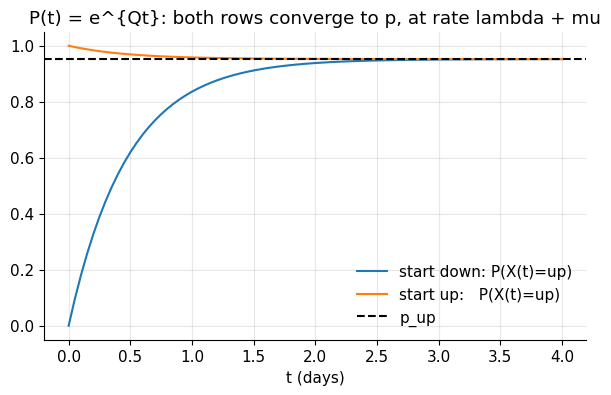

In [6]:
# --- Simulate: time fraction vs jump fraction; and P(X(t)=up) from both starts ----------------
t, x = machine.sample_path(2000, x0="down", rng=rng)
print("fraction of TIME up (sim):", machine.occupancy((t, x))[1].round(4), "   fraction of JUMPS into 'up':", machine.visit_counts((t, x))[1] / max(1, len(x)-1))
ts = np.linspace(0, 4, 81)
plt.figure()
plt.plot(ts, machine.distribution_path([1, 0], ts)[:, 1], label="start down: P(X(t)=up)")
plt.plot(ts, machine.distribution_path([0, 1], ts)[:, 1], label="start up:   P(X(t)=up)")
plt.axhline(lam/(lam+mu), ls="--", c="k", label="p_up"); plt.xlabel("t (days)"); plt.legend()
plt.title("P(t) = e^{Qt}: both rows converge to p, at rate lambda + mu"); plt.show()

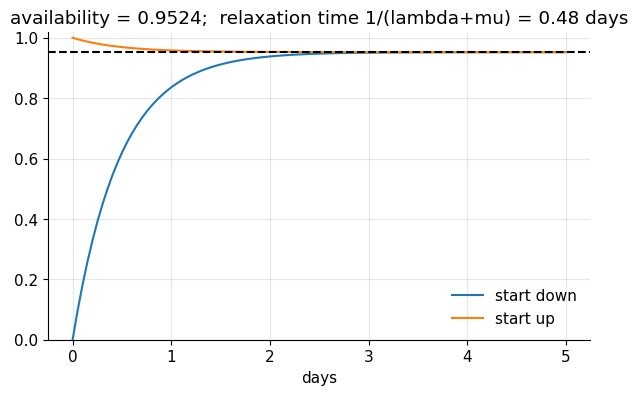

In [7]:
def availability_exp(mean_repair_hours=12.0, mean_uptime_days=10.0):
    """Availability lambda/(lambda+mu) = uptime/(uptime + repair): only the ratio of the means matters."""
    lam_, mu_ = 24/mean_repair_hours, 1/mean_uptime_days
    ch = CTMC([[-lam_, lam_], [mu_, -mu_]]); ts = np.linspace(0, 5, 100)
    plt.figure(); plt.plot(ts, ch.distribution_path([1, 0], ts)[:, 1], label="start down"); plt.plot(ts, ch.distribution_path([0, 1], ts)[:, 1], label="start up")
    plt.axhline(lam_/(lam_+mu_), ls="--", c="k"); plt.ylim(0, 1.02); plt.xlabel("days"); plt.legend()
    plt.title(f"availability = {lam_/(lam_+mu_):.4f};  relaxation time 1/(lambda+mu) = {1/(lam_+mu_):.2f} days"); plt.show()

show(availability_exp, mean_repair_hours=FloatSlider(min=1, max=72, step=1, value=12) if HAS_W else 12.0,
     mean_uptime_days=FloatSlider(min=1, max=60, step=1, value=10) if HAS_W else 10.0)

**Think about it** — (i) $P(t)$ converges at rate $\lambda+\mu$ (Companion Proof 5
has the closed form $e^{-(\lambda+\mu)t}$). What plays the role of the "second
eigenvalue" of Ch.\,4? (ii) Would the availability change if repair times were
*deterministic* with the same mean? (HW3 Part C.)

---
## Problem 2 — Photocopy machines in the long run *(slides pp. 42–43/63)*

> [...] What fraction of time in the long run are zero, one and two machines in
> working condition?

### Model
Node balance, one equation per state (rate out $\times p_j$ = rates in):
$4p_0=0.4p_1$, $2.4p_1=4p_0+0.8p_2$, $0.8p_2=2p_1$ $\Rightarrow$ $p_1=10p_0$, $p_2=25p_0$,
$\boldsymbol p=(1,10,25)/36$. Check: each machine is independently up $\tfrac{2.5}{3}=\tfrac56$ of the
time, so $p_2=(\tfrac56)^2=\tfrac{25}{36}$.

In [8]:
w = np.array([1.0, 10.0, 25.0])              # p1 = 10 p0, p2 = 25 p0
p_photo = w / w.sum()
print("p =", p_photo.round(4), "= (1, 10, 25)/36;  solver:", photocopy.stationary().round(4))
print("binomial check: (1/6)^2, 2(1/6)(5/6), (5/6)^2 =", np.round([1/36, 10/36, 25/36], 4))

p =

 [0.0278 0.2778 0.6944] = (1, 10, 25)/36;  solver: [0.0278 0.2778 0.6944]
binomial check: (1/6)^2, 2(1/6)(5/6), (5/6)^2 = [0.0278 0.2778 0.6944]


In [9]:
_ok = not any(v is Ellipsis for v in np.atleast_1d(p_photo).tolist())
check("p0", p_photo[0] if _ok else None, 1/36,  tol=1e-9)
check("p1", p_photo[1] if _ok else None, 10/36, tol=1e-9)
check("p2", p_photo[2] if _ok else None, 25/36, tol=1e-9)

[OK ] p0: got 0.0277778   (reference 0.0277778)
[OK ] p1: got 0.277778   (reference 0.277778)
[OK ] p2: got 0.694444   (reference 0.694444)


True

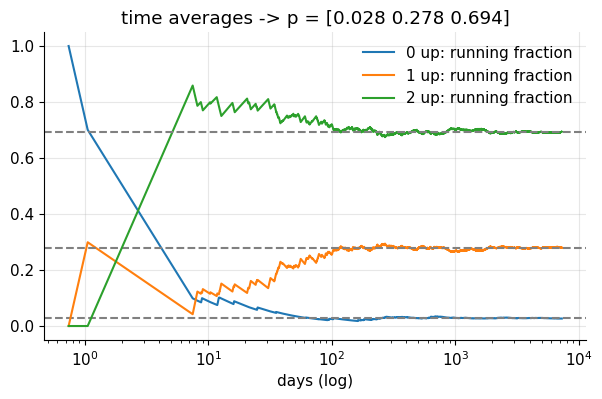

both machines down 2.8% of the time; expected number up: 1.667


In [10]:
# --- Simulate 20 years; running time fractions vs p --------------------------------------------
t, x = photocopy.sample_path(20*365, x0=0, rng=rng)
dt = np.diff(t); occ_run = np.cumsum(np.eye(3)[x[:-1]] * dt[:, None], axis=0) / np.cumsum(dt)[:, None]
plt.figure()
for j in range(3): plt.plot(t[1:], occ_run[:, j], label=f"{j} up: running fraction"); plt.axhline(photocopy.stationary()[j], ls="--", c="gray")
plt.xscale("log"); plt.xlabel("days (log)"); plt.legend(); plt.title(f"time averages -> p = {np.round(photocopy.stationary(), 3)}"); plt.show()
print("both machines down", f"{photocopy.stationary()[0]*100:.1f}% of the time; expected number up:", (photocopy.stationary() @ np.arange(3)).round(3))

**Think about it** — (i) $\boldsymbol p$ is binomial$(2,\tfrac56)$ here. Why does
independence hold with **two** repair persons but not with one? (ii) Write the
node balance equation of state 1 in words: what is "rate out", what are the two
"rates in"?

---
## Problem 3 — The switch: arc balance and the Erlang loss formula *(slides pp. 44–46/63)*

> [...] What is the limiting distribution of the number of calls at the switch?

### Model
Birth & death: cut between $k-1$ and $k$, flow right $=$ flow left:
$\lambda p_{k-1}=k\mu\,p_k$, so $p_k=\frac{1}{k!}\big(\frac\lambda\mu\big)^k p_0$ and
$p_0^{-1}=\sum_{i=0}^K\frac{1}{i!}(\lambda/\mu)^i$. The fraction of time the switch is full,
$p_K$, is the **Erlang loss formula** $B(K,\lambda/\mu)$ — and, by PASTA (Ch.\,8), also the
fraction of calls that are lost.

In [11]:
def switch_p(K, lam, mu):
    """Limiting distribution of the K-channel switch by the arc-balance recursion."""
    a = lam / mu
    w = np.array([a**k / math.factorial(k) for k in range(K+1)])
    return w / w.sum()

K, lam, mu = 4, 3.0, 1.0
Q3 = birth_death([lam]*K, [i*mu for i in range(1, K+1)]).Q
switch = CTMC(Q3, list(range(K+1)))
p_sw = switch_p(K, lam, mu)
print("recursion:", p_sw.round(4)); print("solver   :", switch.stationary().round(4))
print("P(full) = p_K =", p_sw[K].round(4), "  erlang_loss(a=3, K=4) =", round(erlang_loss(lam/mu, K), 4))

recursion: [0.0611 0.1832 0.2748 0.2748 0.2061]
solver   : [0.0611 0.1832 0.2748 0.2748 0.2061]
P(full) = p_K = 0.2061   erlang_loss(a=3, K=4) = 0.2061


In [12]:
_ok = not np.isnan(p_sw).any()
check("p_0", p_sw[0] if _ok else None, switch.stationary()[0], tol=1e-9)
check("p_K (Erlang loss)", p_sw[K] if _ok else None, erlang_loss(lam/mu, K), tol=1e-9)

[OK ] p_0: got 0.0610687   (reference 0.0610687)
[OK ] p_K (Erlang loss): got 0.206107   (reference 0.206107)


True

time full (sim): 0.2018   fraction of calls lost (sim): 0.1991   Erlang B: 0.2061


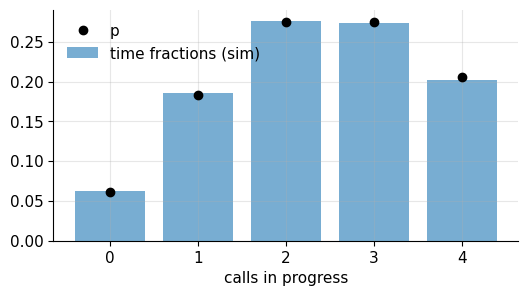

In [13]:
# --- Simulate: lost calls (event average) vs time the switch is full (time average) -------------
t, x = switch.sample_path(20_000, x0=0, rng=rng)
occ = switch.occupancy((t, x))
# count arrivals that found the switch full: while in state K, arrivals come at rate lambda -> simulate them as a thinning of time
T_full = occ[K] * t[-1]; lost = rng.poisson(lam * T_full); accepted = int(np.sum(x[1:] > x[:-1]))
print(f"time full (sim): {occ[K]:.4f}   fraction of calls lost (sim): {lost/(lost+accepted):.4f}   Erlang B: {erlang_loss(lam/mu, K):.4f}")
plt.figure(figsize=(6, 3)); plt.bar(range(K+1), occ, alpha=.6, label="time fractions (sim)"); plt.plot(range(K+1), switch.stationary(), "ko", label="p"); plt.legend(); plt.xlabel("calls in progress"); plt.show()

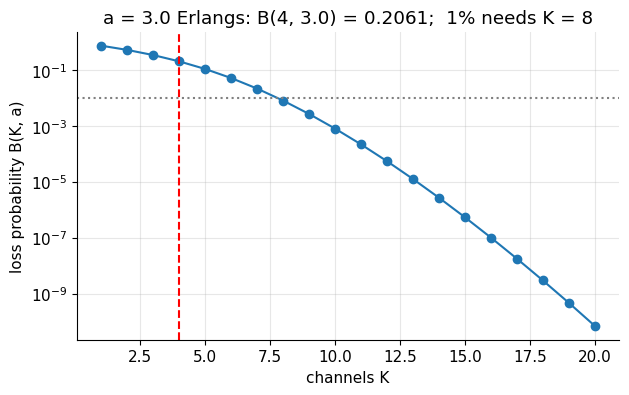

In [14]:
def erlang_exp(K=4, a=3.0):
    """Offered load a = lambda/mu Erlangs: how many channels for 1% loss?"""
    Ks = np.arange(1, 21); B = [erlang_loss(a, k) for k in Ks]
    plt.figure(); plt.semilogy(Ks, B, "o-"); plt.axvline(K, c="r", ls="--"); plt.axhline(0.01, c="gray", ls=":")
    plt.xlabel("channels K"); plt.ylabel("loss probability B(K, a)"); plt.title(f"a = {a} Erlangs: B({K}, {a}) = {erlang_loss(a, K):.4f};  1% needs K = {int(Ks[np.argmax(np.array(B) < 0.01)])}"); plt.show()

show(erlang_exp, K=IntSlider(min=1, max=20, value=4) if HAS_W else 4, a=FloatSlider(min=.5, max=15, step=.5, value=3) if HAS_W else 3.0)

**Think about it** — (i) $p_k\propto a^k/k!$ is a truncated Poisson$(a)$
distribution. Why does the *infinite-channel* switch give exactly Poisson$(a)$?
(ii) The Erlang loss formula is famous for being **insensitive**: it holds for
*any* call-duration distribution with mean $1/\mu$. Test this claim in HW3 Part C.

---
## Problem 4 — Two machines, one repair person: closed form *(slides pp. 47–49/63)*

> [...] What fraction of time is each of the machines up?

### Model
Node balance on the 5-state FCFS chain (CP7 #5) and elimination give, with
$D=\lambda_1\mu_1+\lambda_1\lambda_2+\lambda_2\mu_2$:
$p_1=\frac{\mu_2(\lambda_1+\mu_1+\mu_2)}{D}p_0$, $p_2=\frac{\mu_1(\lambda_2+\mu_1+\mu_2)}{D}p_0$,
$p_3=\frac{\mu_1\mu_2(\lambda_2+\mu_1+\mu_2)}{\lambda_1D}p_0$, $p_4=\frac{\mu_1\mu_2(\lambda_1+\mu_1+\mu_2)}{\lambda_2D}p_0$,
and $\sum p_i=1$. Machine 1 is up in states 0, 1; machine 2 in states 0, 2.

In [15]:
mu1, mu2, lam1, lam2 = 1.0, 2.0, 3.0, 4.0
Q5 = np.zeros((5, 5)); Q5[0, 1], Q5[0, 2], Q5[1, 0], Q5[1, 4], Q5[2, 0], Q5[2, 3], Q5[3, 1], Q5[4, 2] = mu2, mu1, lam2, mu1, lam1, mu2, lam1, lam2
np.fill_diagonal(Q5, -Q5.sum(axis=1)); fcfs = CTMC(Q5)

D = lam1*mu1 + lam1*lam2 + lam2*mu2
w = np.array([1.0, mu2*(lam1+mu1+mu2)/D, mu1*(lam2+mu1+mu2)/D, mu1*mu2*(lam2+mu1+mu2)/(lam1*D), mu1*mu2*(lam1+mu1+mu2)/(lam2*D)])
p_fcfs = w / w.sum()
up1, up2 = p_fcfs[0] + p_fcfs[1], p_fcfs[0] + p_fcfs[2]
print("closed form:", p_fcfs.round(4), "  solver:", fcfs.stationary().round(4))
print(f"machine 1 up {up1:.4f}, machine 2 up {up2:.4f}")

closed form:

 [0.4631 0.2416 0.1409 0.094  0.0604]   solver: [0.4631 0.2416 0.1409 0.094  0.0604]
machine 1 up 0.7047, machine 2 up 0.6040


In [16]:
_ok = not np.isnan(p_fcfs).any()
check("p_0",  p_fcfs[0] if _ok else None, fcfs.stationary()[0], tol=1e-9)
check("p_3",  p_fcfs[3] if _ok else None, fcfs.stationary()[3], tol=1e-9)
check("machine 1 up", up1, fcfs.stationary()[0] + fcfs.stationary()[1], tol=1e-9)
check("machine 2 up", up2, fcfs.stationary()[0] + fcfs.stationary()[2], tol=1e-9)

[OK ] p_0: got 0.463087   (reference 0.463087)
[OK ] p_3: got 0.0939597   (reference 0.0939597)
[OK ] machine 1 up: got 0.704698   (reference 0.704698)
[OK ] machine 2 up: got 0.604027   (reference 0.604027)


np.True_

In [17]:
# --- Simulate 10 years; and compare with two repair persons (machines become independent) --------
t, x = fcfs.sample_path(3650, x0=0, rng=rng); occ = fcfs.occupancy((t, x))
print("sim: machine 1 up", (occ[0]+occ[1]).round(3), " machine 2 up", (occ[0]+occ[2]).round(3))
a1, a2 = lam1/(lam1+mu1), lam2/(lam2+mu2)
print("with TWO repair persons each machine would be independent: availabilities", round(a1, 4), round(a2, 4))
print("FCFS with one repair person costs machine 1", round(a1 - (fcfs.stationary()[0]+fcfs.stationary()[1]), 4), "and machine 2", round(a2 - (fcfs.stationary()[0]+fcfs.stationary()[2]), 4), "of availability")

sim: machine 1 up 0.701  machine 2 up 0.603
with TWO repair persons each machine would be independent: availabilities 0.75 0.6667
FCFS with one repair person costs machine 1 0.0453 and machine 2 0.0626 of availability


**Think about it** — (i) Swap the labels $1\leftrightarrow2$ in the formulas:
$p_1\leftrightarrow p_2$ and $p_3\leftrightarrow p_4$ must swap. Check it numerically.
(ii) Under a priority rule for machine 1 (pre-emptive), machine 1's availability
becomes exactly $\lambda_1/(\lambda_1+\mu_1)$. Why?

---
## Problem 5 — $B$ light bulbs: a pure death process, not a Poisson process *(slides pp. 50–51/63)*

> There are $B$ light bulbs switched on simultaneously; lifetimes are iid
> $\exp(1/\theta)$. $N(t)$ = number of failures by time $t$. (a) Is $N(t)$ a Poisson
> process? (b) What is $E[S_2-S_1]$?

### Model
After $k$ failures only $B-k$ bulbs burn, so the next gap is $\exp((B-k)/\theta)$: the
gaps are independent but **not identically distributed** (and after $B$ failures nothing
happens). (a) **FALSE.** (b) $E[S_2-S_1]=\theta/(B-1)$.

In [18]:
B, theta = 10, 1000.0                           # 10 bulbs, mean life 1000 h
gap_means = theta / (B - np.arange(B))          # E[S_{k+1} - S_k], k = 0..B-1
E_gap2 = theta / (B - 1)
print("E[S_{k+1}-S_k] for k=0..B-1:", gap_means.round(1)); print("E[S_2 - S_1] =", E_gap2)

E[S_{k+1}-S_k] for k=0..B-1: [ 100.   111.1  125.   142.9  166.7  200.   250.   333.3  500.  1000. ]
E[S_2 - S_1] = 111.11111111111111


In [19]:
check("E[S_2 - S_1]", E_gap2, 1000/9, tol=1e-6)
check("E[S_1] = theta/B", None if np.isnan(gap_means[0]) else gap_means[0], 100.0, tol=1e-6)
check("last gap = theta", None if np.isnan(gap_means[-1]) else gap_means[-1], 1000.0, tol=1e-6)

[OK ] E[S_2 - S_1]: got 111.111   (reference 111.111)
[OK ] E[S_1] = theta/B: got 100   (reference 100)
[OK ] last gap = theta: got 1000   (reference 1000)


True

mean gaps (sim): [ 99.5 111.4 124.2 142.4 167.7 201.7 250.4 333.3 499.8 999.5]


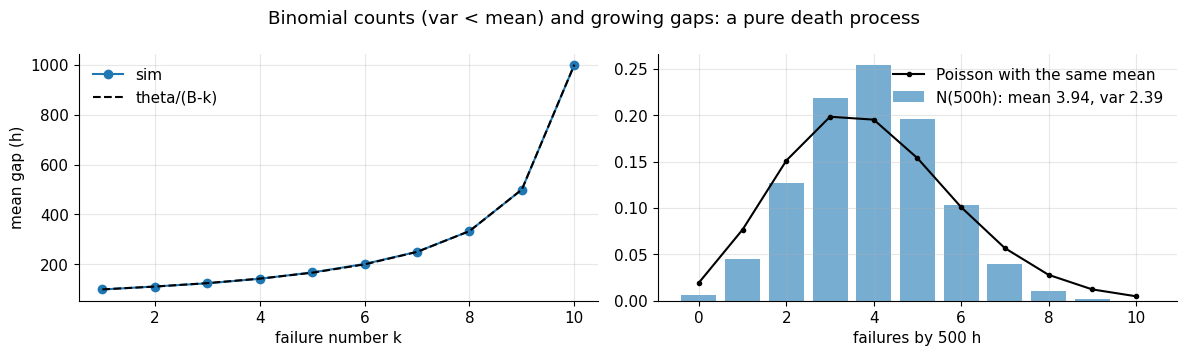

In [20]:
# --- Simulate 20 000 rooms of B bulbs: the gaps grow, and counts are NOT Poisson ---------------
L = rng.exponential(theta, (20_000, B)); S = np.sort(L, axis=1); gaps = np.diff(S, axis=1, prepend=0)
print("mean gaps (sim):", gaps.mean(axis=0).round(1))
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].plot(range(1, B+1), gaps.mean(axis=0), "o-", label="sim"); ax[0].plot(range(1, B+1), theta/(B - np.arange(B)), "k--", label="theta/(B-k)"); ax[0].set_xlabel("failure number k"); ax[0].set_ylabel("mean gap (h)"); ax[0].legend()
# a Poisson process has var = mean for counts in a window; here counts in [0, 500 h]
Nw = (L < 500).sum(axis=1)
ax[1].bar(np.arange(0, B+1), np.bincount(Nw, minlength=B+1)/len(Nw), alpha=.6, label=f"N(500h): mean {Nw.mean():.2f}, var {Nw.var():.2f}")
ax[1].plot(np.arange(0, B+1), stats.poisson(Nw.mean()).pmf(np.arange(0, B+1)), "ko-", ms=3, label="Poisson with the same mean"); ax[1].legend(); ax[1].set_xlabel("failures by 500 h")
plt.suptitle("Binomial counts (var < mean) and growing gaps: a pure death process"); plt.tight_layout(); plt.show()

**Think about it** — (i) $N(500)\sim$ Binomial$(B,1-e^{-500/\theta})$ — derive it.
When $B\to\infty$ with $B/\theta$ fixed, what does it become? (ii) Replace the
dead bulbs *immediately* (a maintenance crew with infinite stock): now the failure
process is exactly $PP(B/\theta)$. Why?

---
## Problem 6 — Barbershop with three stylists: an 8-state CTMC *(slides pp. 52–53/63)*

> A barbershop has 3 servers and no waiting room. Arrivals are $PP(\lambda)$; server
> $i$ takes an $\exp(\mu_i)$ time. When more than one server is free, the arriving
> customer picks one of them at random. Model as an 8-state CTMC and draw the rate diagram.

### Model
State $(x_1,x_2,x_3)$, $x_i=1$ if stylist $i$ is busy. Arrival in a state with $f$ free
stylists: rate $\lambda/f$ to each of the $f$ states with one more busy stylist (lost if
$f=0$); departure from a state with $x_i=1$: rate $\mu_i$ to the state with $x_i=0$.

In [21]:
lam, mus = 3.0, np.array([1/20, 1/15, 1/10]) * 60     # per hour: 3 customers/h; mean cuts 20, 15, 10 min
states6 = [(a, b, c) for a in (0, 1) for b in (0, 1) for c in (0, 1)]
idx = {s: k for k, s in enumerate(states6)}
Q6 = np.zeros((8, 8))
for s in states6:
    free = [i for i in range(3) if s[i] == 0]
    for i in free:                                           # arrival routed to free stylist i
        s2 = list(s); s2[i] = 1; Q6[idx[s], idx[tuple(s2)]] += lam / len(free)
    for i in range(3):                                       # departures
        if s[i] == 1:
            s2 = list(s); s2[i] = 0; Q6[idx[s], idx[tuple(s2)]] += mus[i]
np.fill_diagonal(Q6, -Q6.sum(axis=1))
barber = build_ctmc(Q6, ["".join(map(str, s)) for s in states6])
p6 = barber.stationary()
print("states:", barber.states); print("p:", p6.round(4))
print("P(all three busy) =", p6[idx[(1, 1, 1)]].round(4), "  -> fraction of customers lost (PASTA)")
print("stylist utilisations:", [round(float(sum(p6[idx[s]] for s in states6 if s[i] == 1)), 3) for i in range(3)])

states: ['000', '001', '010', '011', '100', '101', '110', '111']
p: [0.48 0.08 0.12 0.03 0.16 0.04 0.06 0.03]
P(all three busy) = 0.03   -> fraction of customers lost (PASTA)
stylist utilisations: [0.29, 0.24, 0.18]


In [22]:
_Qref = np.zeros((8, 8))
for s in states6:
    free = [i for i in range(3) if s[i] == 0]
    for i in free:
        s2 = list(s); s2[i] = 1; _Qref[idx[s], idx[tuple(s2)]] += lam/len(free)
    for i in range(3):
        if s[i] == 1:
            s2 = list(s); s2[i] = 0; _Qref[idx[s], idx[tuple(s2)]] += mus[i]
np.fill_diagonal(_Qref, -_Qref.sum(axis=1)); _pref = CTMC(_Qref).stationary()
check("q[000 -> 100] = lambda/3", Q6[idx[(0,0,0)], idx[(1,0,0)]], lam/3, tol=1e-9)
check("q[001 -> 101] = lambda/2", Q6[idx[(0,0,1)], idx[(1,0,1)]], lam/2, tol=1e-9)
check("q[111 -> 011] = mu_1",     Q6[idx[(1,1,1)], idx[(0,1,1)]], mus[0], tol=1e-9)
check("q[111 -> 111] = -(mu1+mu2+mu3)", Q6[idx[(1,1,1)], idx[(1,1,1)]], -mus.sum(), tol=1e-9)
check("P(all busy)", None if p6 is None else p6[idx[(1,1,1)]], _pref[idx[(1,1,1)]], tol=1e-9)

[OK ] q[000 -> 100] = lambda/3: got 1   (reference 1)
[OK ] q[001 -> 101] = lambda/2: got 1.5   (reference 1.5)
[OK ] q[111 -> 011] = mu_1: got 3   (reference 3)
[OK ] q[111 -> 111] = -(mu1+mu2+mu3): got -13   (reference -13)
[OK ] P(all busy): got 0.03   (reference 0.03)


np.True_

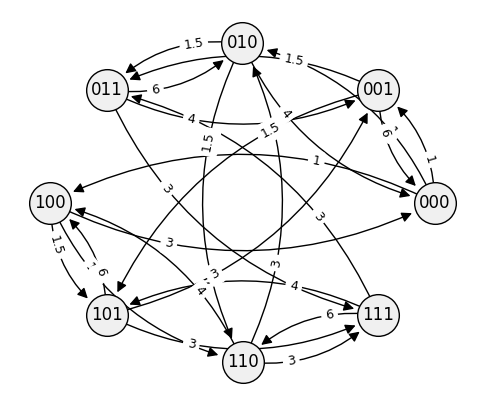

time fractions (sim): [0.485 0.081 0.121 0.03  0.157 0.039 0.058 0.029]
p                   : [0.48 0.08 0.12 0.03 0.16 0.04 0.06 0.03]


In [23]:
# --- Rate diagram and a simulation check ------------------------------------------------------------
if barber:
    fig, ax = plt.subplots(figsize=(6, 5)); barber.plot_rate_diagram(ax=ax, layout="circular", fmt="{:.2g}"); plt.show()
    t, x = barber.sample_path(20_000, x0=0, rng=rng)
    print("time fractions (sim):", barber.occupancy((t, x)).round(3)); print("p                   :", p6.round(3))

**Think about it** — (i) If the customer always picked the *fastest* free
stylist, which arcs change? Is $P(\text{all busy})$ higher or lower? (ii) The
number of busy stylists alone is **not** a CTMC here — why not? (Under what
condition on $\mu_1,\mu_2,\mu_3$ would it be?)

---
## Problem 7 — Next service completion *(slides pp. 54–55/63)*

> For the shop in the previous question, the expected service times are 20, 15, and
> 10 minutes. The servers have been busy for 5, 7 and 6 minutes respectively with
> their current customers. What is the expected remaining time until the next
> service completion?

### Model
Memorylessness: the elapsed 5, 7, 6 minutes are irrelevant. The remaining times are
$\exp(\tfrac1{20}),\exp(\tfrac1{15}),\exp(\tfrac1{10})$ and their minimum is
$\exp(\tfrac1{20}+\tfrac1{15}+\tfrac1{10})=\exp(\tfrac{13}{60})$: $E[R]=\tfrac{60}{13}\approx4.62$ min.
Stylist $i$ finishes first with probability $\mu_i/\sum_j\mu_j$: $\tfrac3{13},\tfrac4{13},\tfrac6{13}$.

In [24]:
rates = np.array([1/20, 1/15, 1/10])            # per minute
E_R = 1 / rates.sum()
p_first = rates / rates.sum()
print(f"E[R] = {E_R:.4f} min = 60/13;   P(stylist i first) = {p_first.round(4)} = (3, 4, 6)/13")

E[R] = 4.6154 min = 60/13;   P(stylist i first) = [0.2308 0.3077 0.4615] = (3, 4, 6)/13


In [25]:
check("E[R] (min)", E_R, 60/13, tol=1e-9)
_ok = not any(v is Ellipsis for v in np.atleast_1d(p_first).tolist())
check("P(stylist 3 first)", p_first[2] if _ok else None, 6/13, tol=1e-9)

[OK ] E[R] (min): got 4.61538   (reference 4.61538)
[OK ] P(stylist 3 first): got 0.461538   (reference 0.461538)


True

In [26]:
# --- Simulate WITH the elapsed times: condition on 'still busy after 5, 7, 6 minutes' ------------------
n = 400_000
S = rng.exponential(1/rates, (n, 3))                    # full service times
elapsed = np.array([5.0, 7.0, 6.0])
keep = (S > elapsed).all(axis=1)                        # runs in which all three are still busy now
R = (S[keep] - elapsed)                                 # remaining times
print(f"kept {keep.mean()*100:.1f}% of runs;  E[min remaining] (sim) = {R.min(axis=1).mean():.3f}   analytic 60/13 = {60/13:.3f}")
print("who finishes first (sim):", (np.bincount(R.argmin(axis=1), minlength=3)/len(R)).round(4))
# contrast: deterministic service times 20, 15, 10 -> remaining 15, 8, 4 -> next completion in exactly 4 minutes
print("deterministic service times would give: next completion in", np.min(np.array([20, 15, 10]) - elapsed), "minutes, always stylist 3")

kept 26.9% of runs;  E[min remaining] (sim) = 4.622   analytic 60/13 = 4.615
who finishes first (sim): [0.2306 0.3054 0.464 ]
deterministic service times would give: next completion in 4.0 minutes, always stylist 3


**Think about it** — (i) If the service times were *Erlang*(2) with the same
means, would the elapsed times matter? In which direction? (ii) The answer
$60/13$ does not depend on *which* customer is served by whom — only on which
stylists are busy. Restate this as a property of the 8-state CTMC.

---
## Problem 8 — A generator with blanks: transient, limiting, cost *(slides pp. 56–58/63)*

> $\{X(t),t\ge0\}$ is a CTMC with state space $\{0,1,2\}$ and generator
> $Q=\begin{pmatrix}\_&2&3\\1&-1&\_\\ \_&0&-2\end{pmatrix}$. Fill up the blanks. What is
> the probability that the CTMC would be in state 2 at time $t=1$ given that it was in
> state 0 at $t=0$? Given that $p_0=2/9$ compute $p_1$ and $p_2$. If the cost incurred
> per unit time in state $i$ is 1,800 won, what is the long-run average cost per unit time?

### Model
Rows sum to 0: blanks are $-5$, $0$, $2$. Transient: $P(1)=e^{Q}$, and
$P(X(1)=2\mid X(0)=0)=[e^{Q}]_{02}$. Limiting: $\boldsymbol pQ=0$ gives $p_1=2p_0$, $p_2=\tfrac32p_0$,
so $\boldsymbol p=(\tfrac29,\tfrac49,\tfrac39)$. Cost: $1{,}800\sum_jp_j=1{,}800$ — no need for $\boldsymbol p$.

In [27]:
Q8 = np.array([[-5.0, 2.0, 3.0],
               [ 1.0, -1.0, 0.0],
               [ 2.0, 0.0, -2.0]])
ctmc8 = build_ctmc(Q8, [0, 1, 2])
P1 = ctmc8.P(1.0)                                  # scipy expm(Q)
prob_02 = P1[0, 2]
p8 = np.array([2/9, 4/9, 3/9])
cost = ctmc8.long_run_cost([1800, 1800, 1800])
print("P(1) =\n", P1.round(4)); print("P(X(1)=2 | X(0)=0) =", prob_02.round(4))
print("p =", p8.round(4), "  solver:", ctmc8.stationary().round(4), "  cost/unit time =", cost)

P(1) =
 [[0.2314 0.3976 0.371 ]
 [0.1988 0.5758 0.2254]
 [0.2473 0.3005 0.4522]]
P(X(1)=2 | X(0)=0) = 0.371
p = [0.2222 0.4444 0.3333]   solver: [0.2222 0.4444 0.3333]   cost/unit time = 1800.0


In [28]:
check_rows0(Q8)
check("P(X(1)=2 | X(0)=0)", prob_02, expm(np.array([[-5, 2, 3], [1, -1, 0], [2, 0, -2]]) * 1.0)[0, 2], tol=1e-6)
_ok = not any(v is Ellipsis for v in np.atleast_1d(p8).tolist())
check("p_1", p8[1] if _ok else None, 4/9, tol=1e-9)
check("p_2", p8[2] if _ok else None, 3/9, tol=1e-9)
check("cost per unit time", cost, 1800, tol=1e-6)

[OK ] rows sum to 0, off-diagonal >= 0: got 0   (reference 0)
[OK ] P(X(1)=2 | X(0)=0): got 0.370991   (reference 0.370991)
[OK ] p_1: got 0.444444   (reference 0.444444)
[OK ] p_2: got 0.333333   (reference 0.333333)
[OK ] cost per unit time: got 1800   (reference 1800)


True

expm       [0,2] = 0.370991
series     [0,2] = 0.370991  (stopped at N* = 34 terms, eps = 1e-10)
(I+Q/N)^N  [0,2] = 0.367933   N = 10
(I+Q/N)^N  [0,2] = 0.370767   N = 100
(I+Q/N)^N  [0,2] = 0.370969   N = 1000
(I+Q/N)^N  [0,2] = 0.370989   N = 10000
solve_ivp  [0,2] = 0.370991


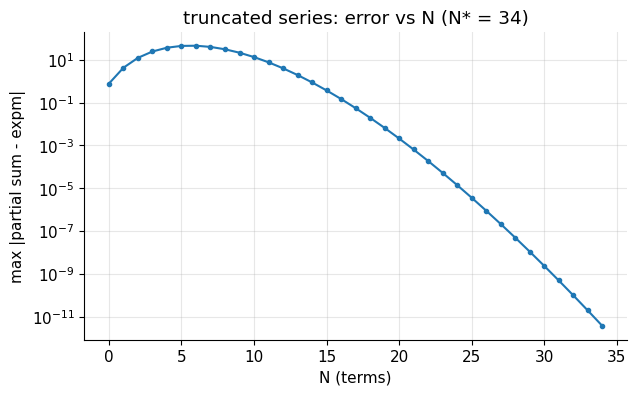

In [29]:
# --- Four ways to compute e^{Q}: expm, truncated series, (I + Q/N)^N, and the forward equations -----
Qr = np.array([[-5.0, 2, 3], [1, -1, 0], [2, 0, -2]]); ref = expm(Qr)
P_series, N_star, partial = expm_series(Qr, 1.0, eps=1e-10)
print("expm       [0,2] =", ref[0, 2].round(6))
print(f"series     [0,2] = {P_series[0, 2]:.6f}  (stopped at N* = {N_star} terms, eps = 1e-10)")
for N in [10, 100, 1000, 10_000]:
    print(f"(I+Q/N)^N  [0,2] = {expm_limit(Qr, 1.0, N)[0, 2]:.6f}   N = {N}")
ode = CTMC(Qr).distribution_path([1, 0, 0], [1.0], method="ode")[0]
print("solve_ivp  [0,2] =", ode[2].round(6))

# how the partial sums of the series converge: the terms grow before they shrink (||Q|| = 5)
err = [np.abs(S - ref).max() for S in partial]
plt.figure(); plt.semilogy(err, "o-", ms=3); plt.xlabel("N (terms)"); plt.ylabel("max |partial sum - expm|"); plt.title(f"truncated series: error vs N (N* = {N_star})"); plt.show()

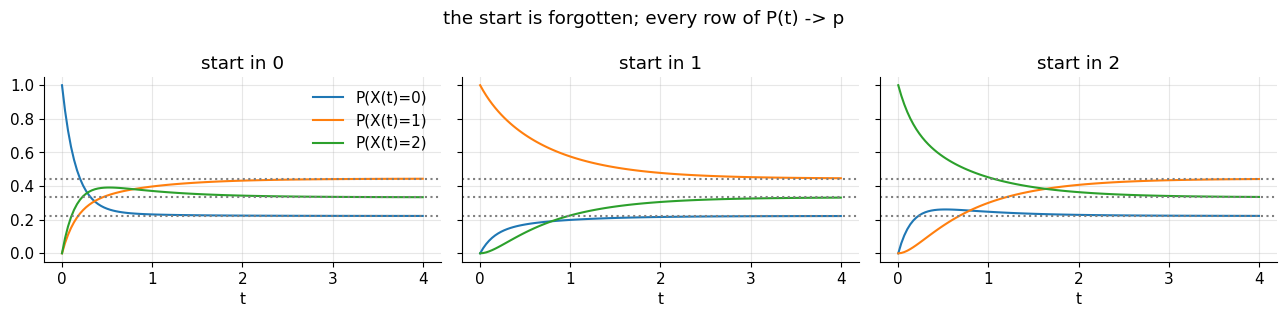

cost per unit time is 1800 in every state -> 1800 regardless of p;  with costs (1800, 0, 0) it would be 400.0


In [30]:
# --- p(t) from each starting state converges to p = (2, 4, 3)/9 -----------------------------------------
ts = np.linspace(0, 4, 121); fig, ax = plt.subplots(1, 3, figsize=(13, 3.2), sharey=True)
for i in range(3):
    path = CTMC(Qr).distribution_path(np.eye(3)[i], ts)
    for j in range(3): ax[i].plot(ts, path[:, j], label=f"P(X(t)={j})")
    for j in range(3): ax[i].axhline([2/9, 4/9, 3/9][j], ls=":", c="gray")
    ax[i].set_title(f"start in {i}"); ax[i].set_xlabel("t")
ax[0].legend(); plt.suptitle("the start is forgotten; every row of P(t) -> p"); plt.tight_layout(); plt.show()
print("cost per unit time is 1800 in every state -> 1800 regardless of p;  with costs (1800, 0, 0) it would be", round(CTMC(Qr).long_run_cost([1800, 0, 0]), 2))

**Think about it** — (i) The truncated series needs $N^\ast=34$ terms although
$t=1$: relate this to $\|Q\|=5$ and to the growth of $5^n/n!$. What would $t=10$
require? (ii) $(I+Q/N)^N$ is the **uniformization**-style approximation: with
$N=10^4$ it is still off in the 5th digit. Why is it so slow, and what does
`expm` do instead?

---
## Problem 9 — One or two repair persons? A dashboard *(slides pp. 60–63/63)*

> Consider 2 identical machines with up times and repair times as described in
> problem #1 above. Would it be better to employ 1 or 2 repair persons for this system?
> If a machine is up, it generates a revenue of $r$ won per unit time. However each
> repair person charges $c$ won per unit time.

### Model
$X(t)$ = number of machines up. Case 1 (one repair person): $\lambda p_0=\mu p_1$,
$\lambda p_1=2\mu p_2$. Case 2 (two): $2\lambda p_0=\mu p_1$, $\lambda p_1=2\mu p_2$.
Reward per unit time in state $j$: $rj-c\cdot(\text{repair persons working})$. Both rewards share the
numerator $N=2\lambda\mu(\mu+\lambda)(r/\mu-c/\lambda)$; the denominators are
$2\mu^2+2\lambda\mu+\lambda^2$ (case 1) and $(\mu+\lambda)^2$ (case 2). So
**two repair persons are better iff $r/\mu>c/\lambda$** — iff one repair pays for itself.

In [31]:
def rewards(lam, mu, r, c):
    """(reward_1, reward_2): long-run reward per unit time with one and with two repair persons."""
    p1 = np.array([2*mu**2, 2*lam*mu, lam**2]); p1 = p1 / p1.sum()          # case 1: p Q = 0 by arc balance
    p2 = np.array([mu**2, 2*lam*mu, lam**2]);   p2 = p2 / p2.sum()          # case 2
    rew1 = p1 @ np.array([-c, r - c, 2*r])                                  # repair person busy in states 0 and 1
    rew2 = p2 @ np.array([-2*c, r - c, 2*r])                                # both busy in state 0, one in state 1
    return rew1, rew2

lam, mu, r, c = 2.0, 0.1, 100.0, 1000.0            # repair rate, failure rate (per day); won per day
rew1, rew2 = rewards(lam, mu, r, c)
print(f"reward with 1 repair person: {rew1:.2f}  with 2: {rew2:.2f}  ->", "two" if rew2 > rew1 else "one")
print("decision rule: r/mu =", r/mu, " vs  c/lambda =", c/lam)

reward with 1 repair person: 95.02  with 2: 95.24  -> two
decision rule: r/mu = 1000.0  vs  c/lambda = 500.0


In [32]:
_c1 = machine_repair(2, 1, mu, lam); _c2 = machine_repair(2, 2, mu, lam)      # (states = number UP; fail_rate = mu, repair_rate = lam)
_r1 = _c1.long_run_cost([-c, r - c, 2*r]); _r2 = _c2.long_run_cost([-2*c, r - c, 2*r])
check("reward, 1 repair person", rew1, _r1, tol=1e-6)
check("reward, 2 repair persons", rew2, _r2, tol=1e-6)

[OK ] reward, 1 repair person: got 95.0226   (reference 95.0226)
[OK ] reward, 2 repair persons: got 95.2381   (reference 95.2381)


True

In [33]:
# --- Simulate both systems for 20 years and compare the average rewards -----------------------------
for k, (ch, rw) in enumerate([(machine_repair(2, 1, mu, lam), [-c, r - c, 2*r]), (machine_repair(2, 2, mu, lam), [-2*c, r - c, 2*r])], start=1):
    t, x = ch.sample_path(20*365, x0=2, rng=rng)
    print(f"{k} repair person(s): average reward per day (sim) = {ch.occupancy((t, x)) @ np.array(rw):.2f}   (analytic {ch.long_run_cost(rw):.2f})")

1 repair person(s): average reward per day (sim) = 92.45   (analytic 95.02)
2 repair person(s): average reward per day (sim) = 98.85   (analytic 95.24)


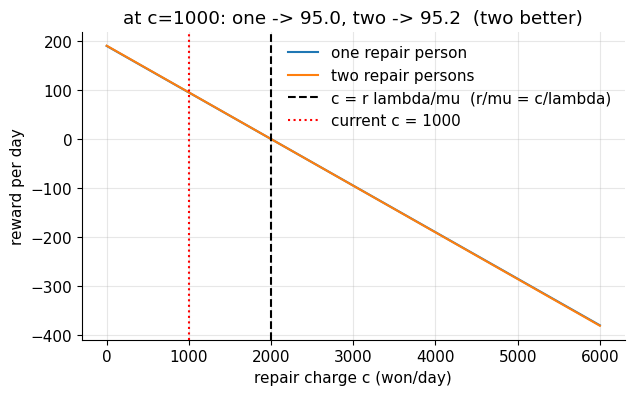

In [34]:
def rewards_ref(lam, mu, r, c):
    """Closed-form rewards of the two policies (independent of your TODO): p by arc balance, then sum_j reward(j) p_j."""
    p1 = np.array([2*mu**2, 2*lam*mu, lam**2]); p1 = p1 / p1.sum()
    p2 = np.array([mu**2, 2*lam*mu, lam**2]);   p2 = p2 / p2.sum()
    return p1 @ np.array([-c, r - c, 2*r]), p2 @ np.array([-2*c, r - c, 2*r])

def repair_dashboard(mean_uptime_days=10.0, mean_repair_hours=12.0, r=100.0, c=1000.0):
    """Rewards of the two policies as a function of the repair charge c; the crossing is at c = r * lambda/mu."""
    mu_, lam_ = 1/mean_uptime_days, 24/mean_repair_hours
    cs = np.linspace(0, 3*r*lam_/mu_, 200)
    R = np.array([rewards_ref(lam_, mu_, r, cc) for cc in cs])
    plt.figure(); plt.plot(cs, R[:, 0], label="one repair person"); plt.plot(cs, R[:, 1], label="two repair persons")
    plt.axvline(r*lam_/mu_, c="k", ls="--", label="c = r lambda/mu  (r/mu = c/lambda)"); plt.axvline(c, c="r", ls=":", label=f"current c = {c:.0f}")
    plt.xlabel("repair charge c (won/day)"); plt.ylabel("reward per day"); plt.legend()
    r1, r2 = rewards_ref(lam_, mu_, r, c); plt.title(f"at c={c:.0f}: one -> {r1:.1f}, two -> {r2:.1f}  ({'two' if r2 > r1 else 'one'} better)"); plt.show()

show(repair_dashboard,
     mean_uptime_days=FloatSlider(min=1, max=60, step=1, value=10) if HAS_W else 10.0,
     mean_repair_hours=FloatSlider(min=1, max=72, step=1, value=12) if HAS_W else 12.0,
     r=FloatSlider(min=10, max=1000, step=10, value=100) if HAS_W else 100.0,
     c=FloatSlider(min=0, max=5000, step=50, value=1000) if HAS_W else 1000.0)

**Think about it** — (i) At the crossing $r/\mu=c/\lambda$ both rewards are
exactly 0. Interpret: revenue per up-period equals the cost of one repair.
(ii) With three machines and one repair person the arc balance still works
(why?); write the decision rule for one vs two repair persons — is it still
independent of the number of machines?

---
## Wrap-up

| question | tool | answer |
|---|---|---|
| machine up/down | $\boldsymbol pQ=0$ (one equation) | $p_{\text{up}}=\lambda/(\lambda+\mu)$; $\pi=(\tfrac12,\tfrac12)\ne p$ |
| photocopy | node balance | $\boldsymbol p=(1,10,25)/36$ |
| switch | arc balance | $p_k\propto(\lambda/\mu)^k/k!$, $p_K=$ Erlang $B$ |
| two machines FCFS | node balance, elimination | closed form with $D$; m/c 1 up $70.5\%$, m/c 2 up $60.4\%$ |
| light bulbs | pure death process | not Poisson; $E[S_2-S_1]=\theta/(B-1)$ |
| barbershop | 8-state generator | $P(\text{all busy})$ = lost fraction |
| next completion | memoryless minimum | $60/13\approx4.62$ min |
| blanks | $e^{Qt}$, $\boldsymbol pQ=0$, $\sum c_jp_j$ | $0.371$; $(2,4,3)/9$; 1,800 |
| repair persons | reward $=\sum_j\text{rew}(j)p_j$ | two iff $r/\mu>c/\lambda$ |

**Next (Ch.\,6–7, Companion Proofs 7–8 and HW3 Part C):** what happens when the
clocks are *not* exponential — insensitivity, and when it fails.